# Apartments in Poland data set 
In this file we perform data cleaning and exploratory data analyis, to prepare the data for training the regression model. We perform following tasks. 
1) Load and concat the csv files from May 2024 aparment prices and June 2024 apartment prices into single dataframe. 
2) Inspect and drop the columns with at least 40% missing records
3) Encode the categorical data 
4) Check collinearity between independent 

In [27]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [2]:
# Load and concat the csv files
df_1=pd.read_csv("apartments_pl_2024_06.csv")
df_2=pd.read_csv("apartments_pl_2024_05.csv")
df_work=pd.concat([df_1, df_2], ignore_index=True)

In [3]:
#Basic inspection 
df_work.head()

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,811891f98a870dfd6e414374a0a85560,szczecin,blockOfFlats,47.00,2.0,6.0,12.0,1981.0,53.428544,14.552812,...,0.085,condominium,concreteSlab,NaN,no,yes,yes,no,yes,449000
1,adaf636d0c44d8d9325bce42403eefee,szczecin,apartmentBuilding,88.22,3.0,1.0,2.0,2000.0,53.449093,14.516844,...,0.668,condominium,brick,premium,yes,yes,no,no,no,950000
2,9b957bd60885a469c96f17b58a914f4b,szczecin,apartmentBuilding,117.00,5.0,4.0,4.0,NaN,53.443096,14.561348,...,0.229,udział,brick,premium,yes,yes,no,no,no,1099000
3,74fef2ff7135bc70797a3fbfd7d44ed6,szczecin,blockOfFlats,33.31,1.0,1.0,4.0,1963.0,53.436100,14.541200,...,0.388,cooperative,brick,NaN,yes,no,no,yes,yes,380000
4,77cc78c75b0d09bf84d6d3124a28803c,szczecin,blockOfFlats,56.00,3.0,7.0,7.0,2018.0,53.447465,14.557811,...,0.178,condominium,brick,premium,yes,yes,yes,yes,yes,799000


In [4]:
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 41732 entries, 0 to 41731
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    41732 non-null  str    
 1   city                  41732 non-null  str    
 2   type                  33211 non-null  str    
 3   squareMeters          41732 non-null  float64
 4   rooms                 41732 non-null  float64
 5   floor                 34759 non-null  float64
 6   floorCount            41311 non-null  float64
 7   buildYear             35153 non-null  float64
 8   latitude              41732 non-null  float64
 9   longitude             41732 non-null  float64
 10  centreDistance        41732 non-null  float64
 11  poiCount              41732 non-null  float64
 12  schoolDistance        41712 non-null  float64
 13  clinicDistance        41608 non-null  float64
 14  postOfficeDistance    41692 non-null  float64
 15  kindergartenDistance  41695 no

## Data Cleaning 

In [5]:
#Inspecting the count of null values in each column 
(df_work.isnull().sum()/len(df_work)*100).round(2)

id                       0.00
city                     0.00
type                    20.42
squareMeters             0.00
rooms                    0.00
floor                   16.71
floorCount               1.01
buildYear               15.76
latitude                 0.00
longitude                0.00
centreDistance           0.00
poiCount                 0.00
schoolDistance           0.05
clinicDistance           0.30
postOfficeDistance       0.10
kindergartenDistance     0.09
restaurantDistance       0.18
collegeDistance          2.73
pharmacyDistance         0.12
ownership                0.00
buildingMaterial        40.76
condition               73.71
hasParkingSpace          0.00
hasBalcony               0.00
hasElevator              4.67
hasSecurity              0.00
hasStorageRoom           0.00
price                    0.00
dtype: float64

#### Since more than 40% of the records are missing from the columns`condition` and `buildingMaterial`, we drop the columns. 
----Additionally, we also drop the column id as it is not relevant to the prediction
----Additionally, we also drop the column city as we have latitude and longitude of each apartment.

In [6]:
df_work.drop(columns=["id", "condition", "buildingMaterial", "city"], inplace=True)

In [7]:
# List of features in the dataset
features_needed=df_work.columns.to_list()

In [8]:
df_work.dropna(inplace=True)

## Feature Engineering 

We will perform encoding on the categorical columns, to check the correlation between independent and dependent variables and multicollinearity between independent variables. 

In [9]:
To_code_list=[feature for feature in df_work.columns if df_work[feature].dtype=="str"] 
To_code_list

['type',
 'ownership',
 'hasParkingSpace',
 'hasBalcony',
 'hasElevator',
 'hasSecurity',
 'hasStorageRoom']

In [10]:
Label_list=To_code_list[2:7]
One_hot_list=To_code_list[0:2]

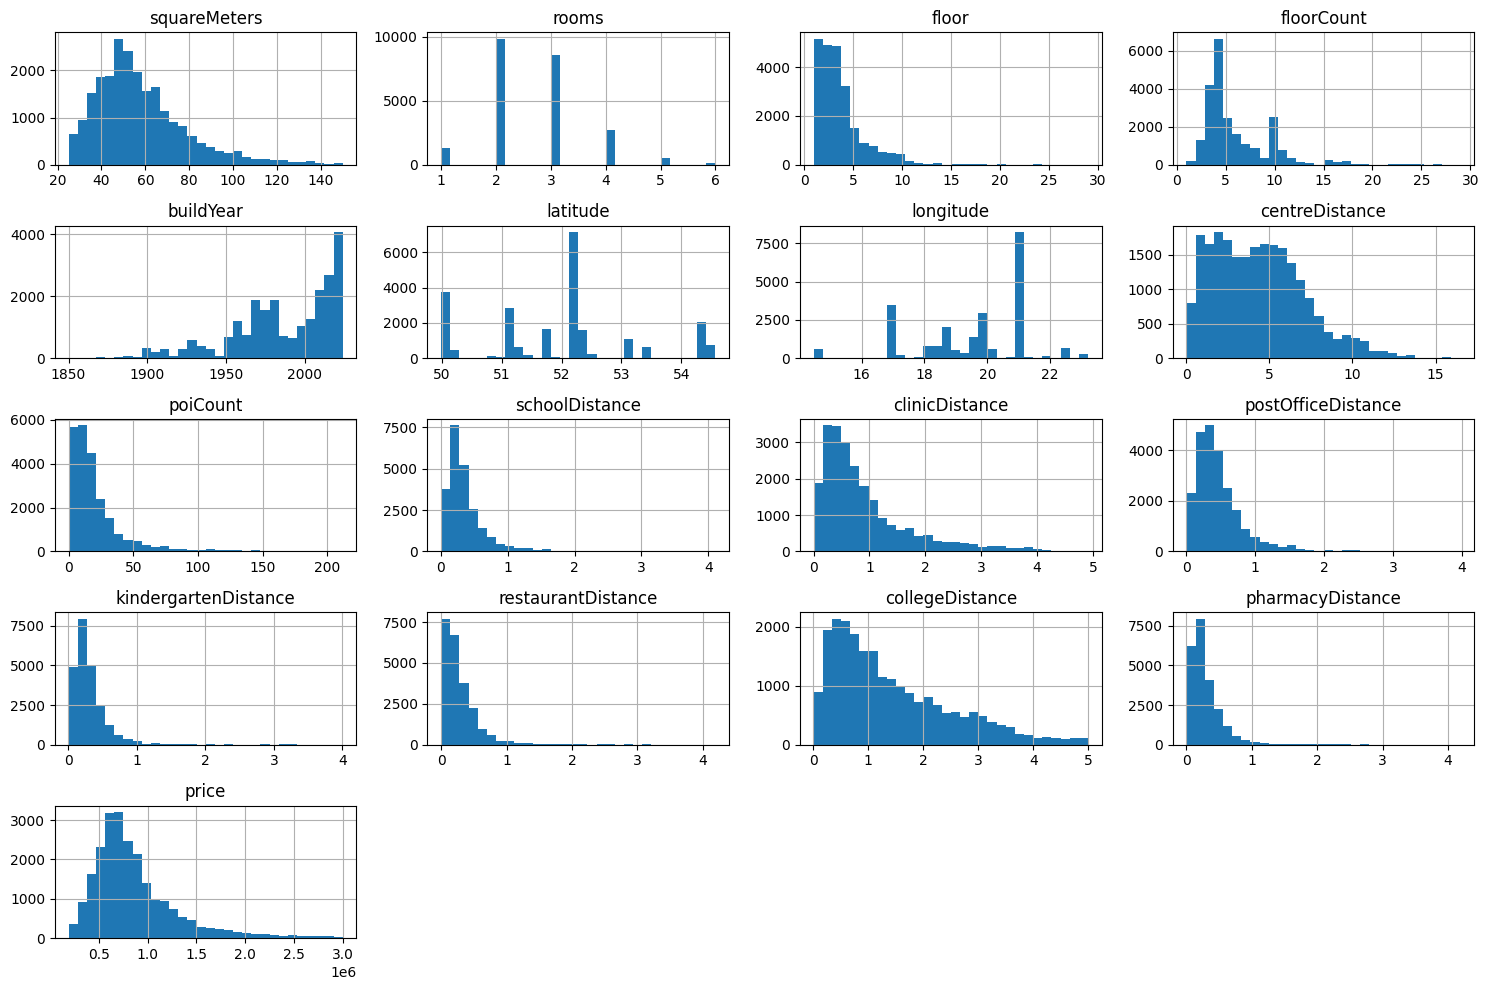

In [11]:
#Frequency distribution of all numerical columns
df_work.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

#### We encode the columns ```hasParkingSpace```,```hasBalcony```,```hasElevator```, ```hasSecurity```, ```hasStorageRoom``` using ```OrdinalEncoder```. 

In [12]:
df_transformed=df_work.copy()
oe=OrdinalEncoder()                                 
for name in Label_list:
   df_transformed[[name]]=oe.fit_transform(df_transformed[[name]])

In [13]:
type(df_transformed)

pandas.DataFrame

#### We encode the columns```type``` and ```ownership``` using ```OneHotEncoder```. 

In [14]:
ct=ColumnTransformer(transformers=[("encoder", OneHotEncoder(), One_hot_list)], remainder="passthrough")
Transformed_array=ct.fit_transform(df_transformed)
column_names=ct.get_feature_names_out()
df_transformed=pd.DataFrame(Transformed_array, columns=column_names, index=df_transformed.index)

In [15]:
# Inspecting the encoded data frame 
df_transformed.head(1)

,encoder__type_apartmentBuilding,encoder__type_blockOfFlats,encoder__type_tenement,encoder__ownership_condominium,encoder__ownership_cooperative,encoder__ownership_udział,remainder__squareMeters,remainder__rooms,remainder__floor,remainder__floorCount,...,remainder__kindergartenDistance,remainder__restaurantDistance,remainder__collegeDistance,remainder__pharmacyDistance,remainder__hasParkingSpace,remainder__hasBalcony,remainder__hasElevator,remainder__hasSecurity,remainder__hasStorageRoom,remainder__price
0,0.0,1.0,0.0,1.0,0.0,0.0,47.0,2.0,6.0,12.0,...,0.245,0.068,0.593,0.085,0.0,1.0,1.0,0.0,1.0,449000.0


In [16]:
# Cleaning the column names to remove the prefix added by OneHotEncoder and OrdinalEncoder
df_transformed.columns=df_transformed.columns.str.removeprefix("encoder__")
df_transformed.columns=df_transformed.columns.str.removeprefix("remainder__")

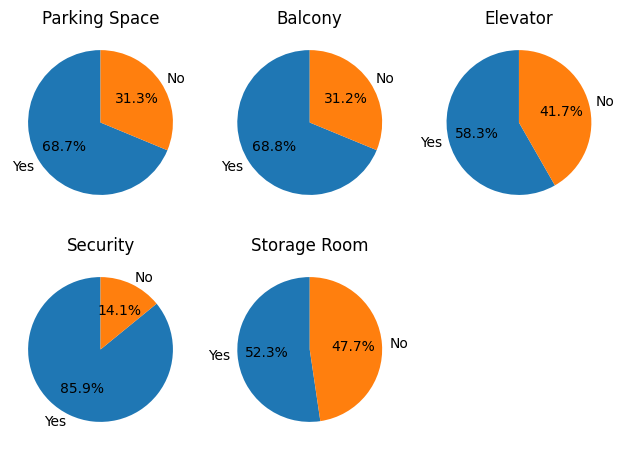

In [17]:
#Percentage of Yes and No for each of the binary categorical features
labels=["Yes", "No"]
titles=["Parking Space", "Balcony", "Elevator", "Security", "Storage Room"]
fig, ax=plt.subplots(2,3)
ax=ax.flatten()
for i,name in enumerate(Label_list):
    percentage=df_transformed[name].value_counts(normalize=True)*100
    ax[i].pie(percentage, labels=labels, startangle=90, autopct="%1.1f%%")
    ax[i].set_title(titles[i])
fig.delaxes(ax[5])
plt.tight_layout()
plt.show()

## Correlation 

In [18]:
df_transformed.corr().drop(index="price", columns="price")

,type_apartmentBuilding,type_blockOfFlats,type_tenement,ownership_condominium,ownership_cooperative,ownership_udział,squareMeters,rooms,floor,floorCount,...,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom
type_apartmentBuilding,1.000000,-0.694190,-0.233692,0.165708,-0.165661,-0.003609,0.111603,0.033614,0.026334,0.073484,...,0.096289,0.039887,-0.017206,0.044666,0.061011,0.229917,0.097389,0.345217,0.171743,-0.340483
type_blockOfFlats,-0.694190,1.000000,-0.537634,-0.231666,0.231596,0.005198,-0.212671,-0.077216,0.097359,0.126865,...,0.024416,-0.019035,0.131686,0.160997,0.039835,-0.123423,0.138708,-0.045582,-0.096231,0.189138
type_tenement,-0.233692,-0.537634,1.000000,0.118826,-0.118787,-0.002795,0.156548,0.064929,-0.162363,-0.257453,...,-0.145776,-0.021012,-0.157729,-0.269802,-0.125280,-0.102606,-0.301453,-0.342821,-0.071191,0.143358
ownership_condominium,0.165708,-0.231666,0.118826,1.000000,-0.999779,-0.018740,0.068148,0.008458,-0.118883,-0.143446,...,0.076153,0.068522,0.029519,0.018821,0.072779,0.012145,-0.028326,0.032419,0.099955,-0.188866
ownership_cooperative,-0.165661,0.231596,-0.118787,-0.999779,1.000000,-0.002303,-0.067991,-0.008205,0.118874,0.143502,...,-0.076230,-0.068445,-0.029528,-0.018960,-0.072743,-0.012054,0.028536,-0.032542,-0.100314,0.189030
ownership_udział,-0.003609,0.005198,-0.002795,-0.018740,-0.002303,1.000000,-0.007990,-0.012097,0.001414,-0.001492,...,0.003002,-0.004224,0.000196,0.006446,-0.002284,-0.004430,-0.009749,0.005560,0.016213,-0.006269
squareMeters,0.111603,-0.212671,0.156548,0.068148,-0.067991,-0.007990,1.000000,0.821964,-0.040500,-0.118089,...,0.012717,0.051767,-0.012688,0.010821,0.014931,0.125312,0.073106,-0.064778,0.078166,-0.031475
rooms,0.033614,-0.077216,0.064929,0.008458,-0.008205,-0.012097,0.821964,1.000000,-0.002955,-0.066031,...,0.026480,0.053627,0.030763,0.028855,0.031348,0.082785,0.094521,-0.055849,0.030516,0.023993
floor,0.026334,0.097359,-0.162363,-0.118883,0.118874,0.001414,-0.040500,-0.002955,1.000000,0.665251,...,-0.066383,-0.080371,-0.089150,-0.069060,-0.095987,-0.023406,-0.012137,0.322778,-0.047881,-0.003844
floorCount,0.073484,0.126865,-0.257453,-0.143446,0.143502,-0.001492,-0.118089,-0.066031,0.665251,1.000000,...,-0.090049,-0.108295,-0.123601,-0.093895,-0.128554,-0.027900,0.025874,0.525904,-0.053742,-0.015949


### Graphical visualisation to see the correlation between different columns 

Text(0.5, 1.0, 'High Correlation Threshold Matrix (>0.5 or <-0.5)')

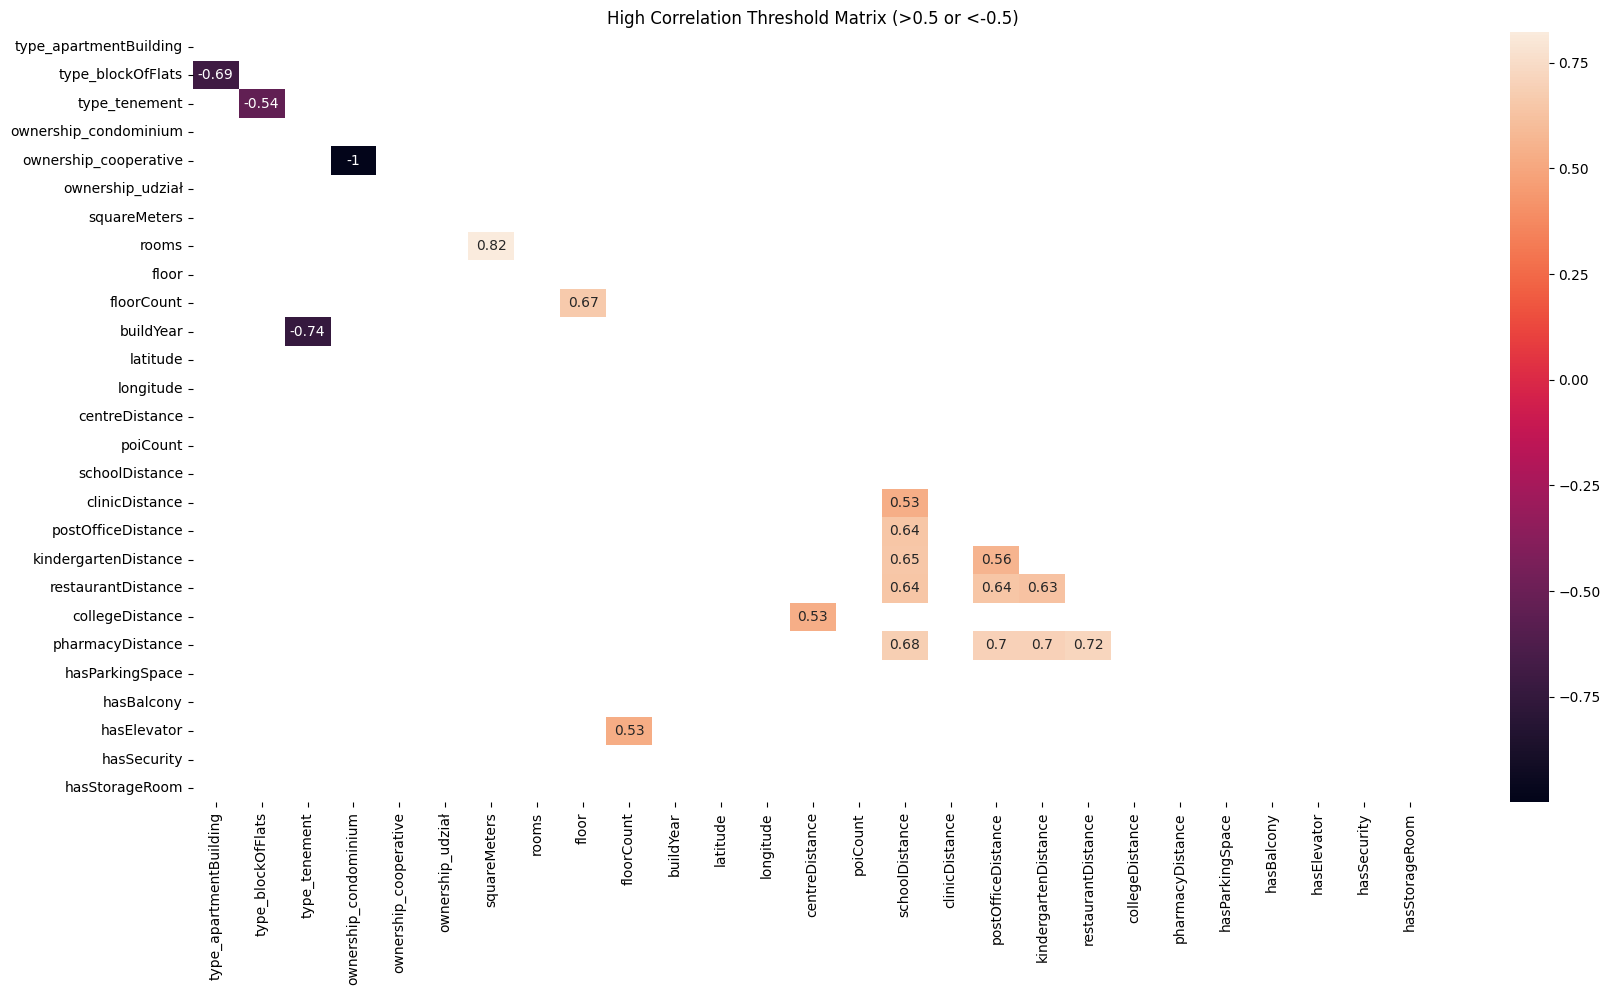

In [19]:
matrix=df_transformed.corr().drop(index="price", columns="price")
filtered_matrix=matrix.copy()
filtered_matrix[abs(filtered_matrix)<0.5]=np.nan
mask = np.triu(np.ones_like(filtered_matrix, dtype=bool))
plt.figure(figsize=(20,10))
sns.heatmap(filtered_matrix, mask=mask, annot=True)
plt.title("High Correlation Threshold Matrix (>0.5 or <-0.5)")

In [20]:
# Correlation between dependent and independent variables 
price_correlations = (
    df_transformed.corr(numeric_only=True)["price"]
      .drop("price")
)
print(price_correlations)

type_apartmentBuilding    0.318517
type_blockOfFlats        -0.346047
type_tenement             0.094331
ownership_condominium     0.120575
ownership_cooperative    -0.120466
ownership_udział         -0.006153
squareMeters              0.684755
rooms                     0.508978
floor                     0.034404
floorCount                0.034792
buildYear                 0.131259
latitude                  0.018665
longitude                 0.231773
centreDistance            0.037299
poiCount                  0.218613
schoolDistance           -0.030715
clinicDistance           -0.153153
postOfficeDistance       -0.033252
kindergartenDistance     -0.031631
restaurantDistance       -0.164599
collegeDistance          -0.053556
pharmacyDistance         -0.036359
hasParkingSpace           0.145007
hasBalcony                0.059768
hasElevator               0.213261
hasSecurity               0.124759
hasStorageRoom           -0.180460
Name: price, dtype: float64


#### We create a function which can check correlation and multicollinearity and return me the features to remove from my data

In [21]:
# def correlation_check(dataset, depen_var, target_threshold=0.1, feature_threshold=0.6):
#     matrix=dataset.corr()
#     # Correlation of each feature with the target (dependent variable)
#     target_correlation=(matrix[depen_var].drop(depen_var).abs())
#     selected_columns=sorted(target_correlation[target_correlation >= target_threshold].index)
#     # Multicollinearity among the selected features 
#     features_matrix=matrix.loc[selected_columns, selected_columns].abs()
#     correlated_col=set()
#     for i in range(len(features_matrix.columns)):
#         for j in range(i):
#             if features_matrix.iloc[i, j]>=feature_threshold:
#                 correlated_col.add(features_matrix.columns[j])
#     return correlated_col

In [22]:
def columns_to_remove(dataset, dependent_col="price", multicollinearity_threshold=0.6):
    matrix=dataset.corr()
    price_correlations = (
        dataset.corr(numeric_only=True)[dependent_col].drop(dependent_col).abs())
    To_remove=set()
    columns=[column for column in matrix.columns if column!=dependent_col]
    for i in range(len(columns)):
        for j in range(i):
            first_col=columns[i]
            second_col=columns[j]
            if abs(matrix.iloc[i,j])>=multicollinearity_threshold:
                if price_correlations[first_col]>=price_correlations[second_col]:
                    To_remove.add(second_col)
                else:
                    To_remove.add(first_col)
    return To_remove
                

In [23]:
To_remove=list(columns_to_remove(df_transformed, dependent_col="price", multicollinearity_threshold=0.6))
To_remove

['pharmacyDistance',
 'floor',
 'type_apartmentBuilding',
 'schoolDistance',
 'rooms',
 'ownership_cooperative',
 'kindergartenDistance',
 'type_tenement',
 'postOfficeDistance']

## Feature selection based on correlation coefficient 

In [24]:
df_transformed.drop(columns=To_remove, inplace=True)

In [25]:
df_transformed.shape

(23171, 19)

In [26]:
df_transformed.to_csv("Encoded_data_Polish_housing.csv", sep=",", index=False)
df_work.to_csv("Cleaned_data_Polish_housing.csv", sep=",", index=False)